# TP2 — Detector de máximo enfoque en el dominio espectral

**Objetivo:** implementar un detector de máximo enfoque sobre `focus_video.mov` usando análisis espectral, como hacen las cámaras digitales.

1. Implementar la métrica del paper *"Image Sharpness Measure for Blurred Images in Frequency Domain"* (De & Masilamani, 2013) y medirla:
   1. sobre todo el frame;
   2. sobre una ROI centrada de 5 % / 10 % del área.
2. Para cada experimento, graficar la métrica frame a frame y marcar **automáticamente** la zona de máximo enfoque.

**Extras:** comparación con ventana de Hann, matriz de enfoque y unsharp masking.

> Los conceptos de Fourier usados acá están explicados paso a paso en `fourier_explicado.ipynb`.

171 frames de 640x360 a 29.97 fps


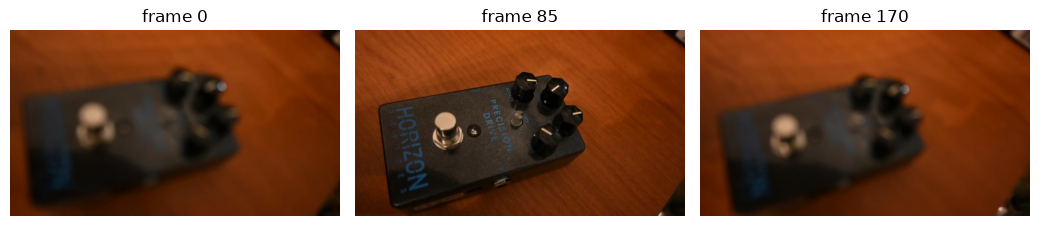

In [1]:
%matplotlib inline
from typing import NamedTuple
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
from focus_utils import read_frames, show, spectrum, hann, gaussian_blur

VIDEO_PATH = "focus_video.mov"

frames, fps = read_frames(VIDEO_PATH)                                  # (N, H, W, 3) BGR
gray = np.stack([cv.cvtColor(f, cv.COLOR_BGR2GRAY) for f in frames])   # (N, H, W)
shape = gray.shape[1:]

print(f"{len(frames)} frames de {shape[1]}x{shape[0]} a {fps:.2f} fps")
show(frames[[0, len(frames) // 2, -1]], ["frame 0", f"frame {len(frames) // 2}", f"frame {len(frames) - 1}"])

## 1. La métrica FM

**FM** es el nombre que le dan los autores: *Frequency domain image blur Measure* (medida de desenfoque en el dominio de la frecuencia). Es un número entre 0 y 1: **más alto = más nítido**.

Algoritmo (sección 3.1 del paper):
1. $F$ = FFT de la imagen $I$ ($M \times N$).
2. $F_c$ = $F$ con el origen desplazado al centro (`fftshift`).
3. $A_F = |F_c|$ (amplitudes).
4. $M_{max} = \max(A_F)$ — siempre es el punto central (brillo promedio).
5. $T_H$ = cantidad de puntos con $A_F > M_{max}/1000$.
6. $FM = T_H / (M \cdot N)$.

**Intuición:** al desenfocar se apagan las rayas finas; menos patrones superan el umbral y FM cae. El umbral es relativo al máximo, así que un cambio de brillo global no altera el conteo. Dividir por el área permite comparar regiones de distinto tamaño.

El parámetro `window` agrega la ventana de Hann (sección 5); por defecto está apagado para respetar el paper.

In [2]:
def fm_sharpness(gray, window=False, ratio=1000):
    # Frequency domain image blur Measure (De & Masilamani, 2013).
    img = gray.astype(np.float64)
    if window:
        img = img * hann(img.shape)
    af = np.abs(np.fft.fftshift(np.fft.fft2(img)))  # el shift no altera el conteo, se deja por fidelidad al paper
    return np.count_nonzero(af > af.max() / ratio) / img.size

## 2. Regiones y experimentos

Una región es un rectángulo `Rect(x, y, w, h)` (misma convención que OpenCV). El experimento 1 es simplemente la región "frame completo", así la misma función mide todo.

Para que la ROI ocupe una fracción $p$ del área sin deformarse, cada lado se escala por $\sqrt{p}$.

In [3]:
class Rect(NamedTuple):
    x: int
    y: int
    w: int
    h: int

    def crop(self, img):
        return img[self.y:self.y + self.h, self.x:self.x + self.w]


def rect_at(shape, cx, cy, rw, rh):
    # Rect centrado en (cx, cy) de tamaño (rw, rh); todo relativo al frame.
    h, w = shape
    rw, rh = round(rw * w), round(rh * h)
    return Rect(round(cx * w - rw / 2), round(cy * h - rh / 2), rw, rh)


def center_roi(shape, area_frac):
    side = np.sqrt(area_frac)
    return rect_at(shape, 0.5, 0.5, side, side)


def fm_curve(gray, rect, **kw):
    return np.array([fm_sharpness(rect.crop(g), **kw) for g in gray])


regions = {
    "frame completo": rect_at(shape, 0.5, 0.5, 1, 1),
    "ROI 10%": center_roi(shape, 0.10),
    "ROI 5%": center_roi(shape, 0.05),
}
colors = dict(zip(regions, ["tab:blue", "tab:orange", "tab:green"]))
curves = {name: fm_curve(gray, r) for name, r in regions.items()}
for name, r in regions.items():
    print(f"{name:15s} {r}  área = {r.w * r.h / (shape[0] * shape[1]):.1%}")

frame completo  Rect(x=0, y=0, w=640, h=360)  área = 100.0%
ROI 10%         Rect(x=219, y=123, w=202, h=114)  área = 10.0%
ROI 5%          Rect(x=248, y=140, w=143, h=80)  área = 5.0%


## 3. Detección automática del máximo enfoque

La curva cruda tiene ruido de frame a frame, así que:
1. **Suavizado** con promedio móvil de `k` frames.
2. **Pico** = máximo de la curva suavizada → frame de máximo enfoque.
3. **Zona de máximo enfoque** = tramo contiguo alrededor del pico donde la curva normalizada al rango $[0, 1]$ supera `level` (90 %).

Normalizar al rango hace que el criterio no dependa de la escala absoluta de FM (que cambia mucho entre frame completo y ROI).

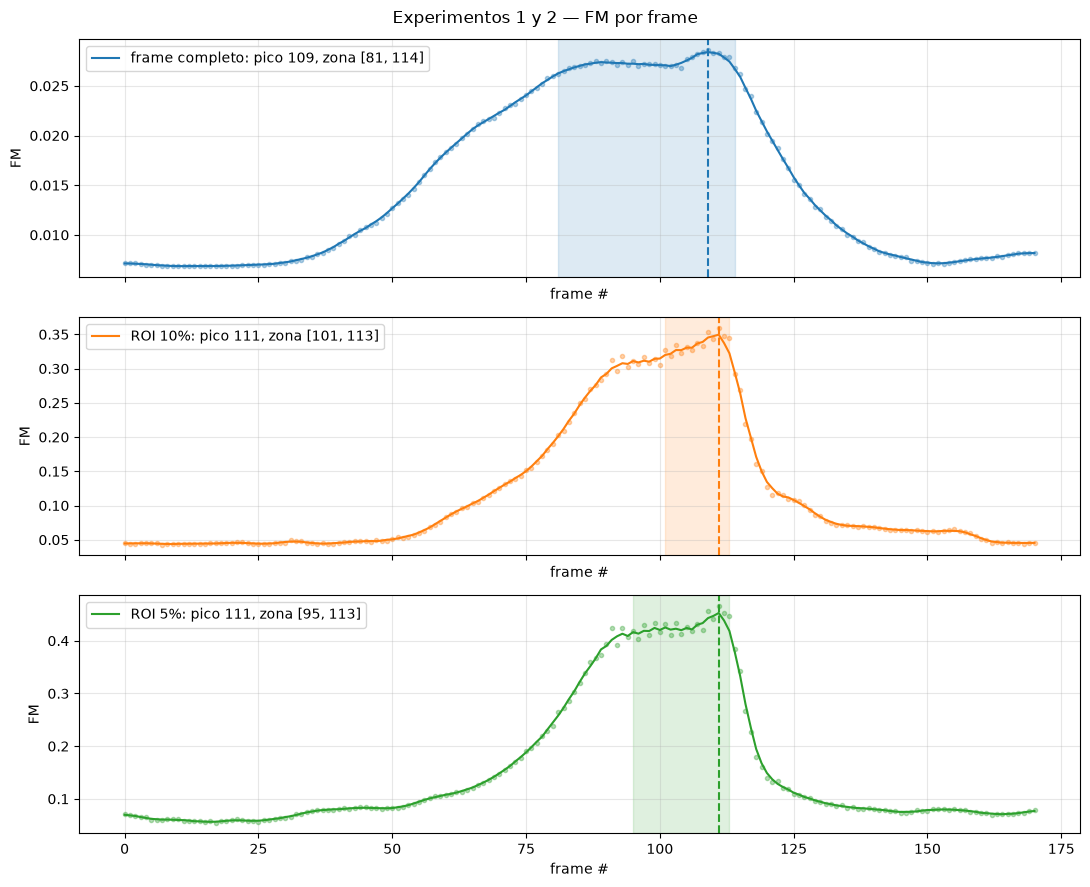

región                  pico        zona   FM min   FM max contraste
frame completo           109   [81, 114]   0.0069   0.0284      4.1x
ROI 10%                  111  [101, 113]   0.0438   0.3496      8.0x
ROI 5%                   111   [95, 113]   0.0565   0.4527      8.0x


In [4]:
class Focus(NamedTuple):
    peak: int
    start: int
    end: int
    smooth: np.ndarray


def moving_average(x, k):
    return np.convolve(np.pad(x, k // 2, mode="edge"), np.ones(k) / k, mode="valid")


def detect_focus(curve, k=5, level=0.9):
    s = moving_average(curve, k)
    n = (s - s.min()) / np.ptp(s)
    peak = start = end = int(n.argmax())
    while start > 0 and n[start - 1] >= level:
        start -= 1
    while end < len(n) - 1 and n[end + 1] >= level:
        end += 1
    return Focus(peak, start, end, s)


def plot_focus(ax, curve, f, label, color):
    ax.plot(curve, ".", color=color, alpha=0.35)
    ax.plot(f.smooth, color=color, label=f"{label}: pico {f.peak}, zona [{f.start}, {f.end}]")
    ax.axvspan(f.start, f.end, color=color, alpha=0.15)
    ax.axvline(f.peak, color=color, ls="--")
    ax.set(xlabel="frame #", ylabel="FM")
    ax.grid(alpha=0.3)
    ax.legend(loc="upper left")


def plot_curves(curves, title, colors=colors):
    focus = {name: detect_focus(c) for name, c in curves.items()}
    fig, axs = plt.subplots(len(curves), 1, figsize=(11, 3 * len(curves)), sharex=True)
    for ax, (name, c) in zip(np.atleast_1d(axs), curves.items()):
        plot_focus(ax, c, focus[name], name, colors[name])
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()
    return focus


def summary(curves, focus):
    print(f"{'región':22s} {'pico':>5s} {'zona':>11s} {'FM min':>8s} {'FM max':>8s} {'contraste':>9s}")
    for name, c in curves.items():
        f = focus[name]
        lo, hi = f.smooth.min(), f.smooth.max()
        print(f"{name:22s} {f.peak:5d} {f'[{f.start}, {f.end}]':>11s} {lo:8.4f} {hi:8.4f} {hi / lo:8.1f}x")


focus = plot_curves(curves, "Experimentos 1 y 2 — FM por frame")
summary(curves, focus)

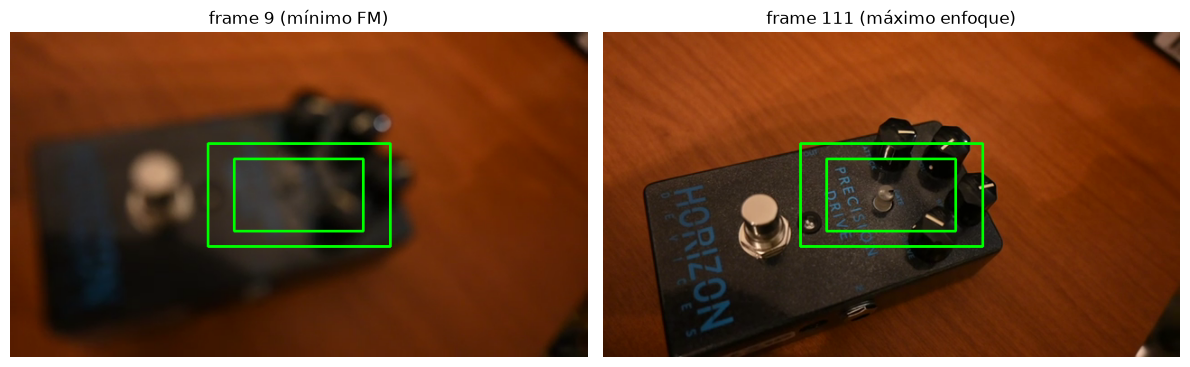

In [5]:
def draw_rects(frame, rects, color, thickness=2):
    out = frame.copy()
    for r in rects:
        cv.rectangle(out, (r.x, r.y), (r.x + r.w, r.y + r.h), color, thickness)
    return out


worst = int(focus["ROI 10%"].smooth.argmin())
best = focus["ROI 10%"].peak
rois = [regions["ROI 10%"], regions["ROI 5%"]]
show([draw_rects(frames[i], rois, (0, 255, 0)) for i in (worst, best)],
     [f"frame {worst} (mínimo FM)", f"frame {best} (máximo enfoque)"], size=6)

**Análisis de los experimentos 1 y 2**

- **Frame completo:** la curva sube de forma gradual y tiene una meseta ancha. La zona detectada es [81, 114], el pico está en el frame 109 y el contraste máximo/mínimo es de apenas **4×**. Hay dos motivos. El frame incluye fondo y periferia a distintas profundidades, que se enfocan en momentos distintos y "promedian" la curva. Además, la mayor parte del área es madera o carcasa lisa, sin detalle, y eso diluye la métrica: FM nunca pasa de 0.03.
- **ROI 10 % y 5 %:** ambas coinciden en el **frame 111** y el contraste se duplica (**8×**). La ROI mira sólo el centro del pedal (texto *PRECISION DRIVE* y perillas), que tiene mucho detalle y está a una profundidad casi única. La caída después del frame 113 es abrupta: el plano de foco pasa por el objeto y lo abandona en pocos frames.
- **5 % vs 10 %:** mismo pico y mismo contraste. La ROI del 5 % tiene la mitad de píxeles, así que la curva es más ruidosa y la meseta más plana, lo que ensancha la zona detectada ([95, 113] contra [101, 113]).
- En los tres casos la zona de máximo enfoque cae en el mismo tramo del video (~frames 95–113) y la imagen lo confirma: en el frame 111 el texto y las perillas se leen nítidos.

## 4. Validación: lo que el paper predice

Se toma el frame de máximo enfoque y se lo desenfoca artificialmente con gaussianas de $\sigma$ creciente (como la figura 5a del paper). Si la métrica está bien implementada, FM debe **caer monótonamente**.

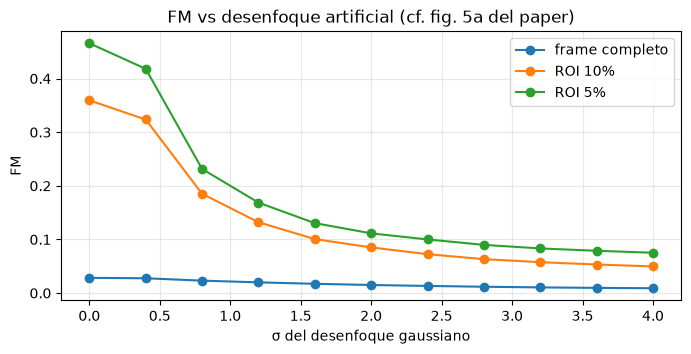

In [6]:
sharp = gray[best]
sigmas = np.arange(0, 4.01, 0.4)
fig, ax = plt.subplots(figsize=(8, 3.5))
for name, r in regions.items():
    fm = [fm_sharpness(r.crop(gaussian_blur(sharp, s))) for s in sigmas]
    ax.plot(sigmas, fm, "o-", color=colors[name], label=name)
ax.set(xlabel="σ del desenfoque gaussiano", ylabel="FM", title="FM vs desenfoque artificial (cf. fig. 5a del paper)")
ax.grid(alpha=0.3)
ax.legend()
plt.show()

## 5. Ventana de Hann

La FFT asume que la imagen es periódica: las discontinuidades entre bordes opuestos introducen alta frecuencia espuria (la cruz del espectro), que infla FM con un piso independiente del enfoque. La ventana de Hann atenúa los bordes hacia cero y elimina ese artefacto. Aunque el paper no la usa, se evalúa su efecto sobre las curvas.

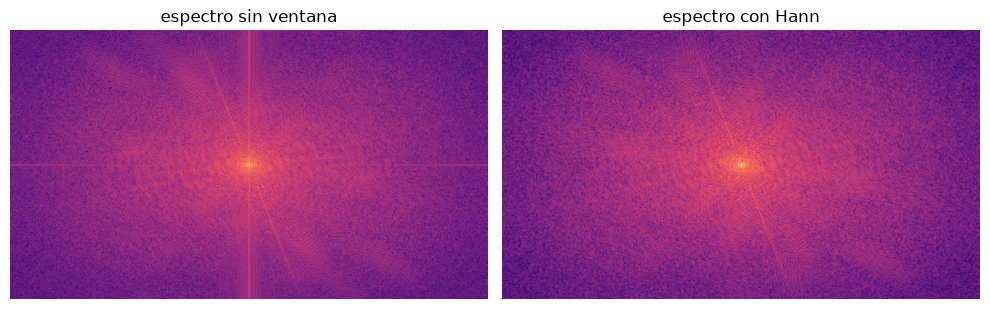

In [7]:
g = gray[best].astype(np.float64)
show([spectrum(g), spectrum(g * hann(g.shape))], ["espectro sin ventana", "espectro con Hann"], cmap="magma", size=5)

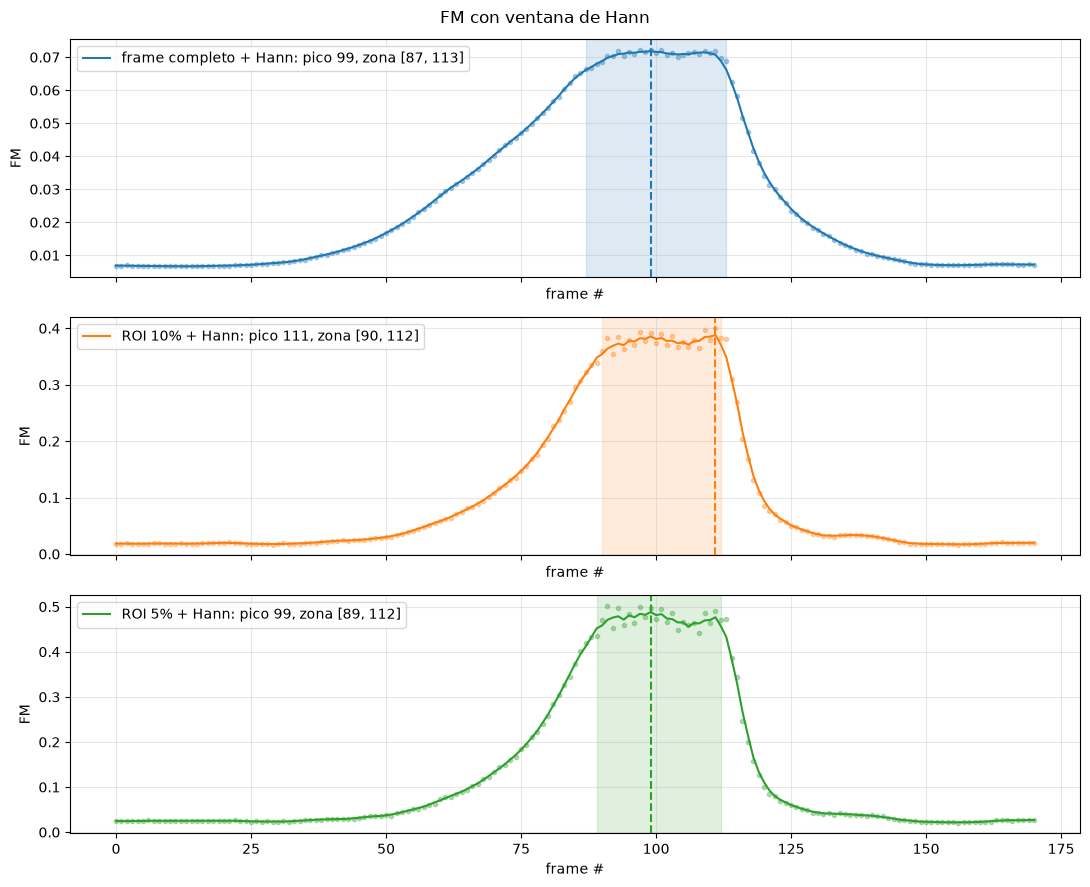

región                  pico        zona   FM min   FM max contraste
frame completo           109   [81, 114]   0.0069   0.0284      4.1x
ROI 10%                  111  [101, 113]   0.0438   0.3496      8.0x
ROI 5%                   111   [95, 113]   0.0565   0.4527      8.0x
frame completo + Hann     99   [87, 113]   0.0067   0.0719     10.8x
ROI 10% + Hann           111   [90, 112]   0.0172   0.3882     22.6x
ROI 5% + Hann             99   [89, 112]   0.0218   0.4881     22.4x


In [8]:
curves_hann = {f"{name} + Hann": fm_curve(gray, r, window=True) for name, r in regions.items()}
colors_hann = {f"{name} + Hann": c for name, c in colors.items()}
focus_hann = plot_curves(curves_hann, "FM con ventana de Hann", colors_hann)
summary(curves | curves_hann, focus | focus_hann)

**Análisis: con vs sin ventana de Hann**

- La ventana **baja el piso** de la curva en los frames borrosos. En la ROI 10 %, el mínimo pasa de 0.044 a 0.017, porque desaparece el "detalle falso" de las costuras. El máximo se mantiene o sube. Resultado: el **contraste casi se triplica** (8× → 22×, y 4× → 11× en el frame completo). Es más fácil separar "enfocado" de "desenfocado".
- La meseta de máximo enfoque queda más plana y definida: la zona es **[~88, 113]** en las tres regiones, y esa coincidencia es buena señal.
- Efecto secundario: dentro de una meseta plana, el `argmax` puede caer en cualquier punto (99 o 111), porque las diferencias son del orden del ruido. **El resultado robusto del detector es la zona, no un único frame.** Si hace falta un solo frame, conviene tomar el centro de la zona o el pico de la ROI.

## 6. Matriz de enfoque

Como el autofoco de una cámara: una grilla de $7 \times 7$ ROIs chicas sobre el centro del frame. Cada celda tiene su propia curva FM.
- **Curva global** = promedio de las celdas → detección del frame de máximo enfoque.
- **Mapa de "frame de máximo enfoque" por celda**: si la escena tiene profundidad, distintas celdas se enfocan en distintos frames (el plano de foco barre la escena).
- Sobre el frame de máximo enfoque se pintan en verde las celdas que están ≥ 90 % de su propio máximo.
- Se compara el mapa sin y con ventana de Hann (sección 5).

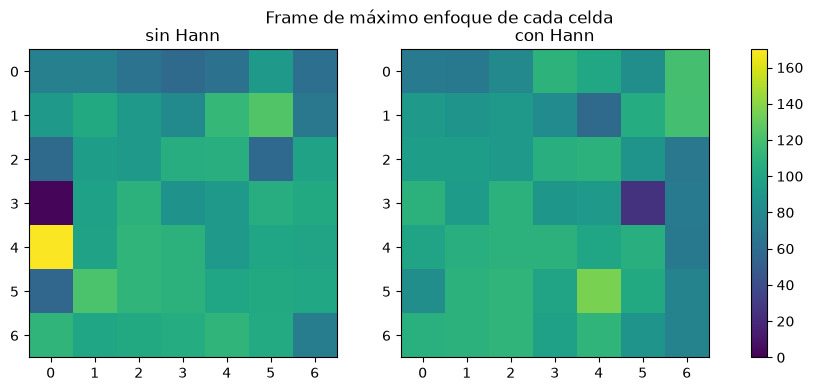

In [9]:
def grid_rects(shape, n=7, span=0.5, fill=0.6):
    # n x n celdas repartidas sobre la fracción `span` central; cada una ocupa `fill` de su paso.
    pitch = span / n
    centers = 0.5 - span / 2 + pitch * (np.arange(n) + 0.5)
    return [rect_at(shape, cx, cy, pitch * fill, pitch * fill) for cy in centers for cx in centers]


N_GRID = 7
grid = grid_rects(shape, N_GRID)
G = {w: np.stack([fm_curve(gray, r, window=w) for r in grid], axis=1) for w in (False, True)}  # (frames, celdas)
fig, axs = plt.subplots(1, 2, figsize=(11, 4))
for ax, (w, g) in zip(axs, G.items()):
    im = ax.imshow(g.argmax(axis=0).reshape(N_GRID, N_GRID), cmap="viridis", vmin=0, vmax=len(gray) - 1)
    ax.set_title("con Hann" if w else "sin Hann")
fig.suptitle("Frame de máximo enfoque de cada celda")
fig.colorbar(im, ax=axs)
plt.show()

**¿Por qué los mapas son tan distintos?** Sin ventana aparecen celdas con valores absurdos, por ejemplo una celda cuyo "mejor" frame es el 3 (totalmente desenfocado). Esa celda cae sobre la tapa metálica del pulsador. En el frame 3 la atraviesa un degradé borroso, y en el mosaico que imagina la FFT ese degradé genera costuras fuertes en los bordes de la celda: da **FM = 0.99**, el valor máximo posible, en una imagen borrosa. En cambio, en el frame 99 la celda es metal liso (desvío 2.2) y da FM = 0.05.

En una celda de 27×15 píxeles el borde es proporcionalmente enorme, así que **el efecto de borde domina la métrica**. Con la ventana de Hann el mapa se vuelve mucho más coherente. Quedan apenas un par de celdas atípicas, en zonas sin textura. Por eso la matriz se calcula con Hann.

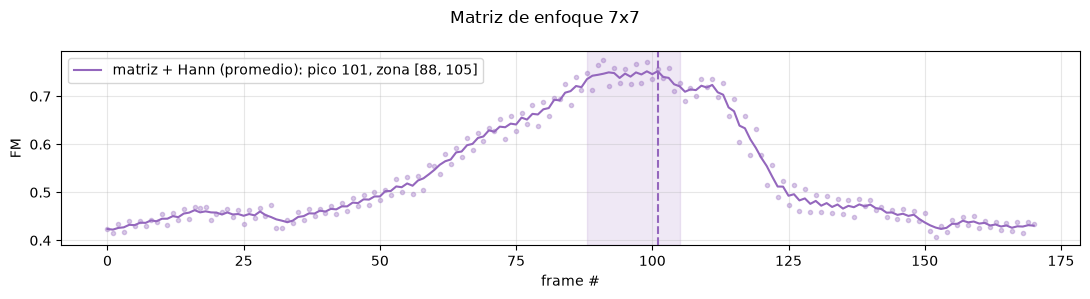

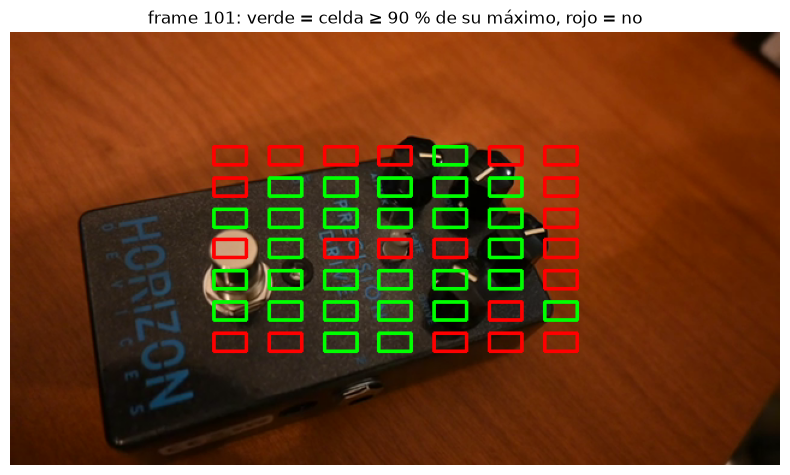

In [10]:
Gw = G[True]
focus_grid = plot_curves({"matriz + Hann (promedio)": Gw.mean(axis=1)}, "Matriz de enfoque 7x7", {"matriz + Hann (promedio)": "tab:purple"})

peak = focus_grid["matriz + Hann (promedio)"].peak
in_focus = Gw[peak] >= 0.9 * Gw.max(axis=0)
overlay = draw_rects(frames[peak], [r for r, ok in zip(grid, in_focus) if ok], (0, 255, 0))
overlay = draw_rects(overlay, [r for r, ok in zip(grid, in_focus) if not ok], (0, 0, 255))
show([overlay], [f"frame {peak}: verde = celda ≥ 90 % de su máximo, rojo = no"], size=8)

**Análisis de la matriz de enfoque**

- La curva promedio va de ~0.4 a ~0.75, con una forma similar a la de la diapositiva del TP. Detecta la zona **[88, 105]** con pico en el frame 101, consistente con las ROIs.
- El mapa con Hann muestra **profundidad**. El centro del pedal alcanza su máximo alrededor de los frames 100–115. La fila superior y la columna derecha (perillas que sobresalen y la madera del borde, a otra distancia de la cámara) lo alcanzan antes, ~60–80. El plano de foco recorre la escena en profundidad, y la matriz dice qué parte está nítida en cada momento. Es exactamente la información que usa una cámara para elegir *dónde* enfocar.
- Las celdas rojas del frame de máximo enfoque son, en su mayoría, zonas sin textura (madera, carcasa negra lisa) o partes a otra profundidad. Ahí la métrica no tiene nada que medir. Una cámara real descartaría esas celdas por bajo contraste.

## 7. Unsharp masking

Visto en clase: $g = (k+1)\,f - k\,f_B$, donde $f_B$ es la imagen desenfocada con una gaussiana. Restar la versión borrosa aísla las altas frecuencias, y sumarlas de nuevo las **realza**. En el lenguaje de Fourier: vuelve a subir la amplitud de las rayas finas que el desenfoque había atenuado.

Se aplica a todos los frames y se recalcula la curva sobre la ROI 10 %. Para medir si **la zona de enfoque se expande**, se usa el umbral absoluto que definía la zona en el video original (90 % del rango original) y se cuentan los frames que lo superan antes y después.

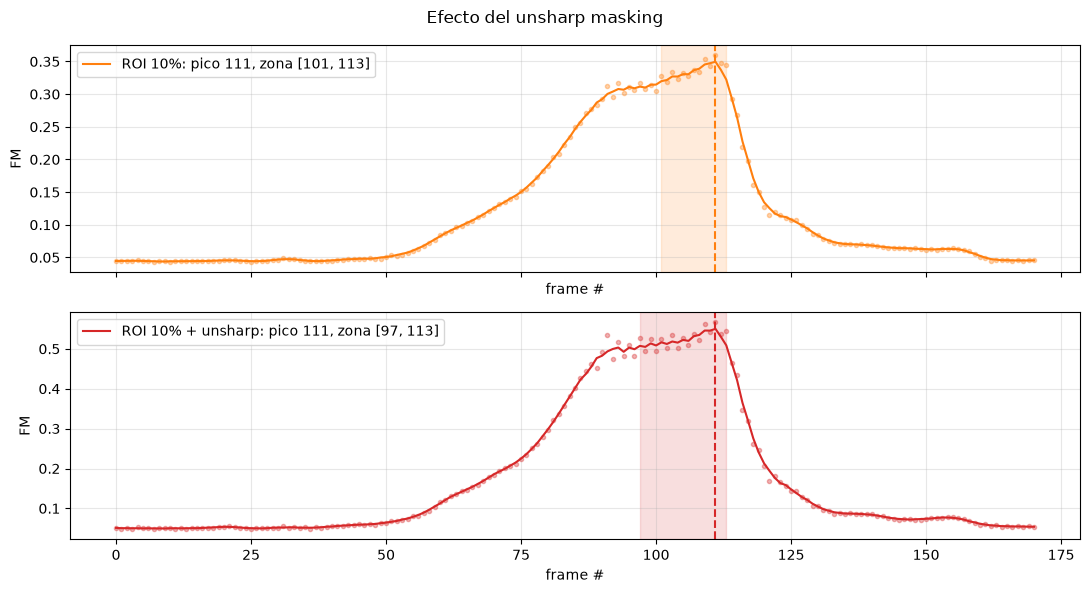

ROI 10%           :  13 frames sobre FM=0.319  ->  [101, 113]
ROI 10% + unsharp :  36 frames sobre FM=0.319  ->  [82, 117]


In [11]:
def unsharp_mask(img, k=1.0, sigma=2.0):
    return cv.addWeighted(img, 1 + k, cv.GaussianBlur(img, (0, 0), sigma), -k, 0)


frames_usm = np.stack([unsharp_mask(f) for f in frames])
gray_usm = np.stack([cv.cvtColor(f, cv.COLOR_BGR2GRAY) for f in frames_usm])

roi = regions["ROI 10%"]
pair = {"ROI 10%": curves["ROI 10%"], "ROI 10% + unsharp": fm_curve(gray_usm, roi)}
focus_usm = plot_curves(pair, "Efecto del unsharp masking", {"ROI 10%": "tab:orange", "ROI 10% + unsharp": "tab:red"})

s0 = focus["ROI 10%"].smooth
threshold = s0.min() + 0.9 * np.ptp(s0)
for name, f in focus_usm.items():
    idx = np.flatnonzero(f.smooth >= threshold)
    print(f"{name:18s}: {idx.size:3d} frames sobre FM={threshold:.3f}  ->  [{idx.min()}, {idx.max()}]")

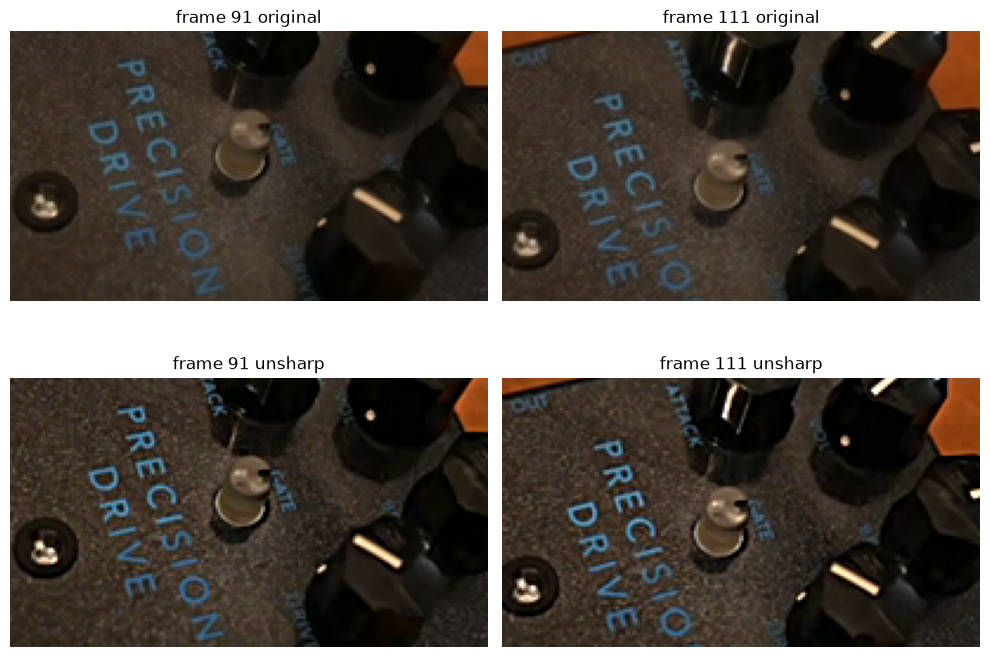

In [12]:
edge = max(focus["ROI 10%"].start - 10, 0)
show([roi.crop(frames[i]) for i in (edge, best)] + [roi.crop(frames_usm[i]) for i in (edge, best)],
     [f"frame {edge} original", f"frame {best} original", f"frame {edge} unsharp", f"frame {best} unsharp"], cols=2, size=5)

**Análisis del unsharp masking**

- Con el umbral absoluto del video original, la zona "enfocada" pasa de **13 a 36 frames** ([101, 113] → [82, 117]): el realce **expande la zona de enfoque**. Los frames que estaban "casi enfocados" recuperan suficientes componentes de alta frecuencia como para superar el umbral. Visualmente, el texto del frame del borde de la zona se ve más definido.
- Los frames muy desenfocados casi no cambian (0.045 → 0.05). Unsharp masking **amplifica lo que queda** de alta frecuencia, pero no puede inventar detalle que el desenfoque ya borró.
- Hay que tomarlo con cuidado: FM cuenta componentes sobre un umbral y **no distingue detalle real de ruido**. El realce también amplifica ruido y artefactos de compresión, y eso sube FM sin mejorar la imagen. Por eso `k` y `sigma` deben ser moderados (acá `k=1`, `sigma=2`).

## 8. Conclusiones

| experimento | pico | zona de máximo enfoque | contraste |
|---|---|---|---|
| frame completo | 109 | [81, 114] | 4× |
| ROI 10 % | 111 | [101, 113] | 8× |
| ROI 5 % | 111 | [95, 113] | 8× |
| ROI 10 % + Hann | 111 | [90, 112] | 22× |
| matriz 7×7 + Hann | 101 | [88, 105] | 1.8× |

1. La métrica FM del paper **funciona como detector de enfoque**: es monótona frente al desenfoque gaussiano (sección 4) y todas las variantes coinciden en que el máximo enfoque está en los **frames ~90–113, con pico en el 111**.
2. **Medir sobre una ROI central es claramente mejor** que medir sobre todo el frame: duplica el contraste de la curva y afina la zona, porque ignora el fondo a otra profundidad y las zonas sin textura.
3. **La ventana de Hann** (no incluida en el paper) elimina el falso detalle de los bordes de la FFT y casi triplica el contraste. En regiones chicas (matriz de enfoque) **es imprescindible**: sin ella la métrica se equivoca por completo.
4. El detector (suavizado + pico + tramo sobre el 90 % del rango) devuelve la zona automáticamente. **La zona es más robusta que el pico**: cuando la curva tiene meseta, el `argmax` puede moverse entre frames igual de nítidos.
5. **Limitaciones de FM:** el umbral depende del máximo (el brillo promedio), no del contraste local, y el conteo no distingue detalle real de ruido. Por eso regiones lisas, bordes o realces agresivos pueden inflarla.